# 05. Regimes and Structural Breaks

This is the core notebook of the project. The earlier notebooks established whether volatility, dependence and transmission changed after COVID-19. Here we ask the strongest version of the research question: **did the market move into distinct regimes, and do structural breaks cluster around the COVID period?**

We focus on two objects that summarize the structure of risk particularly well:
- the rolling variance of the S&P 500, as a direct proxy for aggregate market risk;
- the rolling correlation between the S&P 500 and the US 10Y yield change, as a direct proxy for the equity/rates risk structure.

## 1. Setup

The notebook combines two complementary approaches from the course. A Markov-switching model asks whether the equity/rate dependence alternates between latent regimes. The Bai-Perron style multiple-break search asks whether the same series display discrete structural breaks at particular dates.

In [1]:
from _notebook_setup import bootstrap_notebook

bootstrap_notebook()

import pandas as pd
import matplotlib.pyplot as plt

from project2_regime_utils import (
    load_regime_data,
    fit_two_state_markov,
    markov_summary_table,
    smoothed_probability_table,
    plot_smoothed_probabilities,
    run_break_detection,
    plot_breaks,
    pre_post_break_count,
    save_regime_outputs,
)
from project2_data_utils import ensure_output_dirs, save_figure

ensure_output_dirs()

## 2. Build the two regime-state variables

We first construct the two series that will carry the regime analysis:
- a rolling annualized S&P 500 variance;
- a rolling 52-week SPX / UST rolling correlation.

These are natural state variables because they summarize both the level of risk and the way risk is transmitted between equities and sovereign yields.

In [2]:
rolling_variance, spx_ust_corr = load_regime_data()

print(f"Rolling variance sample: {rolling_variance.shape}")
print(f"Rolling correlation sample: {spx_ust_corr.shape}")

rolling_variance.head(), spx_ust_corr.head()

Rolling variance sample: (5424, 3)
Rolling correlation sample: (5235, 2)


(        date   sp500  sp500_rolling_variance
 0 2000-04-17  3.2548                731.3795
 1 2000-04-18  2.8260                762.0376
 2 2000-04-19 -0.9857                766.7364
 3 2000-04-26 -1.1197                744.3590
 4 2000-04-27  0.2686                739.7157,
         date  spx_ust_rolling_corr
 0 2001-03-15                0.1425
 1 2001-03-16                0.1423
 2 2001-03-19                0.1476
 3 2001-03-20                0.1538
 4 2001-03-21                0.1483)

## 3. Two-state Markov switching on the SPX / UST correlation

A two-state Markov-switching model is a natural way to summarize whether the equity-rate relation spends time in clearly different dependence regimes. For reproducibility, we keep the random seed fixed before estimation, and we interpret the two states using their estimated correlation means rather than by imposing labels ex ante.

In [3]:
markov_result = fit_two_state_markov(spx_ust_corr)
markov_summary = markov_summary_table(markov_result)
markov_summary

C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,regime,estimated_mean,estimated_variance,avg_smoothed_probability,label
0,0.0000,0.4693,0.0146,0.5602,higher-correlation regime
1,1.0000,0.0431,0.0180,0.4398,lower-correlation regime
2,NaN,NaN,NaN,0.4395,share of time in lower-correlation regime


## 4. Smoothed regime probabilities

The smoothed probabilities tell us when the model believes the market is more likely to be in one regime rather than the other. This is often more informative than the raw parameter table because it shows whether the COVID period coincides with a persistent shift in the inferred state of the market.

In [4]:
smoothed_probs = smoothed_probability_table(markov_result)
smoothed_probs.head()

,date,regime_0_probability,regime_1_probability
0,2001-03-15,0.0001,0.9999
1,2001-03-16,0.0000,1.0000
2,2001-03-19,0.0000,1.0000
3,2001-03-20,0.0000,1.0000
4,2001-03-21,0.0000,1.0000


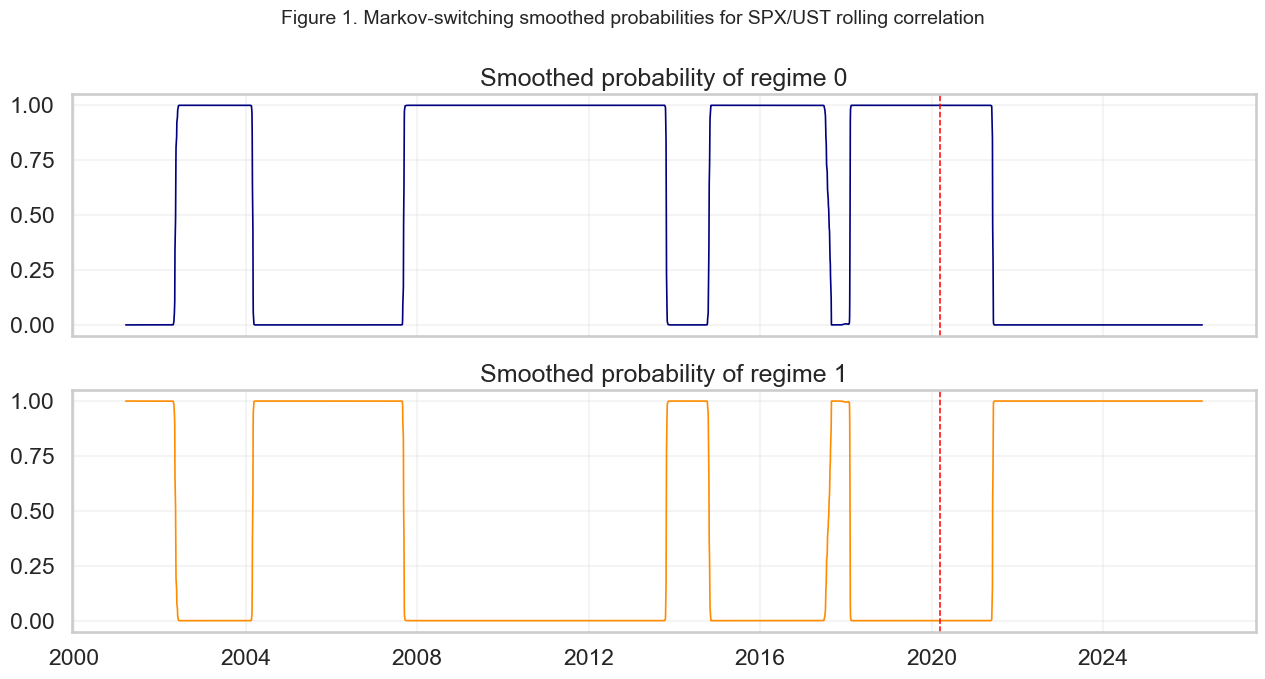

In [5]:
probability_figure = plot_smoothed_probabilities(smoothed_probs)
save_figure(probability_figure, "05_markov_smoothed_probabilities.png")
plt.show()

## 5. Bai-Perron style breaks on S&P 500 rolling variance

A latent-regime model is useful, but it does not tell us whether the data also contain sharp discrete breaks. We therefore run a Bai-Perron style multiple-break detection on the rolling variance of the S&P 500. If several break dates cluster around COVID or later, that is direct evidence that the risk process changed structurally rather than only temporarily.

In [6]:
variance_series = rolling_variance.set_index("date")["sp500_rolling_variance"]
variance_breaks = run_break_detection(variance_series)
variance_breaks

,break_index,break_date,series_mean_before_break
0,1755,2008-09-17,310.9178
1,1855,2009-03-19,441.5470
2,2480,2012-02-24,459.8589


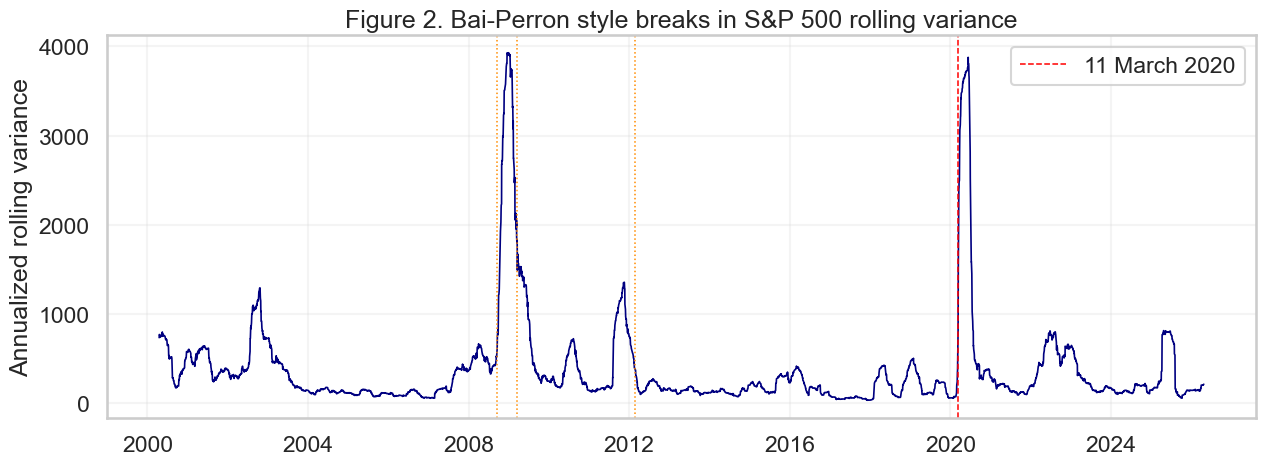

In [7]:
variance_break_figure = plot_breaks(
    variance_series,
    variance_breaks,
    title="Figure 2. Bai-Perron style breaks in S&P 500 rolling variance",
    ylabel="Annualized rolling variance",
)
save_figure(variance_break_figure, "05_sp500_variance_breaks.png")
plt.show()

## 6. Bai-Perron style breaks on the SPX / UST rolling correlation

We repeat the same exercise on the rolling SPX / UST correlation. This is especially important because the project is not only about more or less volatility. It is also about whether the relationship between risky assets and sovereign rates was reorganized after COVID.

In [8]:
correlation_series = spx_ust_corr.set_index("date")["spx_ust_rolling_corr"]
correlation_breaks = run_break_detection(correlation_series)
correlation_breaks

,break_index,break_date,series_mean_before_break
0,635,2004-04-22,0.3626
1,1385,2007-11-02,0.1928
2,4240,2021-06-23,0.3598


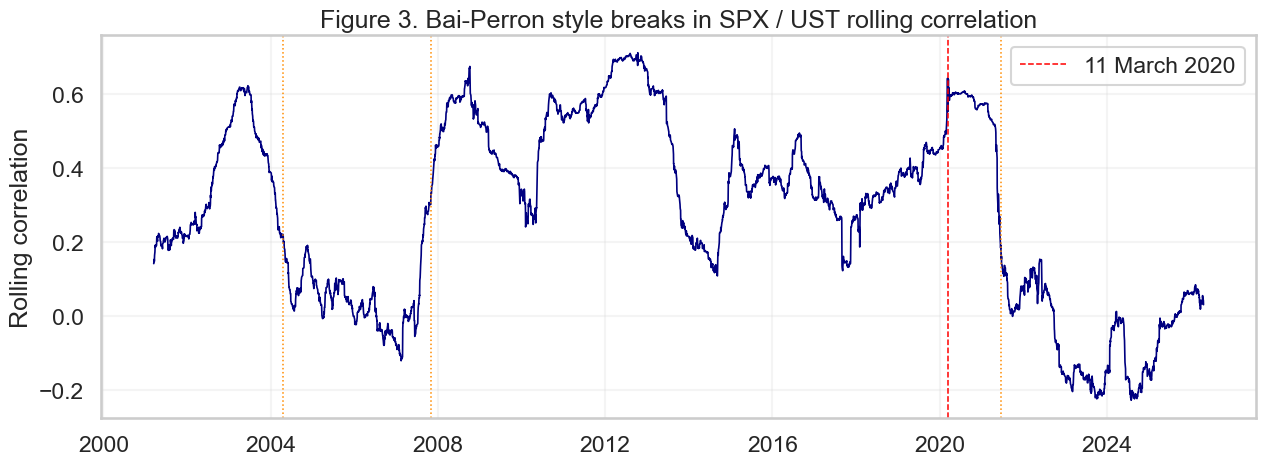

In [9]:
correlation_break_figure = plot_breaks(
    correlation_series,
    correlation_breaks,
    title="Figure 3. Bai-Perron style breaks in SPX / UST rolling correlation",
    ylabel="Rolling correlation",
)
save_figure(correlation_break_figure, "05_spx_ust_corr_breaks.png")
plt.show()

## 7. Count how breaks are distributed around COVID

A simple but useful summary is to count how many estimated breaks fall before and after the COVID date. This is not a test by itself, but it helps translate the break analysis into a direct answer to the research question.

In [10]:
variance_break_counts = pre_post_break_count(variance_breaks)
correlation_break_counts = pre_post_break_count(correlation_breaks)

print("Break counts for S&P 500 rolling variance")
variance_break_counts

Break counts for S&P 500 rolling variance


,n_breaks_pre_covid,n_breaks_post_covid
0,3,0


In [11]:
print("Break counts for SPX / UST rolling correlation")
correlation_break_counts

Break counts for SPX / UST rolling correlation


,n_breaks_pre_covid,n_breaks_post_covid
0,2,1


## 8. Save the regime and break outputs

We save the Markov summary, the smoothed probabilities and the two break tables because these objects are the core evidence for the final synthesis notebook.

In [12]:
save_regime_outputs(markov_summary, smoothed_probs, variance_breaks, correlation_breaks)
print("Saved regime and break outputs under outputs/project2/")

Saved regime and break outputs under outputs/project2/


## 9. Main takeaways from notebook 05

This notebook provides the strongest direct evidence on whether the structure of risk changed after COVID-19. If the Markov model shows persistent switches in the probability of the lower- or higher-correlation regime, and if the break detection finds multiple breaks in the S&P 500 variance or SPX / UST dependence around the COVID period, then the case for a structural post-COVID reorganization of market risk becomes much stronger.